In [7]:
# install kaggle
!pip install -q kaggle

# setup kaggle credentials
import os, json

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_data = {
    "username": "YOUR_KAGGLE_USERNAME",
    "key": "YOUR_KAGGLE_API_KEY"
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_data, f)

!chmod 600 /root/.kaggle/kaggle.json


# download BreakHis 400X dataset
!kaggle datasets download -d forderation/breakhis-400x -q


# unzip
!unzip -q breakhis-400x.zip -d dataset


# check dataset folder
import os

base_path = "dataset"
print("Top folders:", os.listdir(base_path))

Dataset URL: https://www.kaggle.com/datasets/forderation/breakhis-400x
License(s): CC0-1.0
replace dataset/BreaKHis 400X/test/benign/SOB_B_A-14-22549AB-400-001.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: Top folders: ['BreaKHis 400X']


In [8]:
# create dataframe from dataset folders

import os
import pandas as pd

data = []

train_path = "dataset/BreaKHis 400X/train"
test_path = "dataset/BreaKHis 400X/test"

# read train folder
for label in os.listdir(train_path):
    class_path = os.path.join(train_path, label)
    for img in os.listdir(class_path):
        data.append([os.path.join(class_path, img), label])

# read test folder
for label in os.listdir(test_path):
    class_path = os.path.join(test_path, label)
    for img in os.listdir(class_path):
        data.append([os.path.join(class_path, img), label])

# create dataframe
df = pd.DataFrame(data, columns=["image_path", "label"])

print("dataset loaded")
print("shape:", df.shape)
print(df.head())

dataset loaded
shape: (1693, 2)
                                          image_path      label
0  dataset/BreaKHis 400X/train/malignant/SOB_M_LC...  malignant
1  dataset/BreaKHis 400X/train/malignant/SOB_M_DC...  malignant
2  dataset/BreaKHis 400X/train/malignant/SOB_M_DC...  malignant
3  dataset/BreaKHis 400X/train/malignant/SOB_M_DC...  malignant
4  dataset/BreaKHis 400X/train/malignant/SOB_M_DC...  malignant


In [9]:
# split again for validation from train

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

print("train:", len(train_df))
print("val:", len(val_df))

train: 1354
val: 339


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE
)

Found 1354 validated image filenames belonging to 2 classes.
Found 339 validated image filenames belonging to 2 classes.


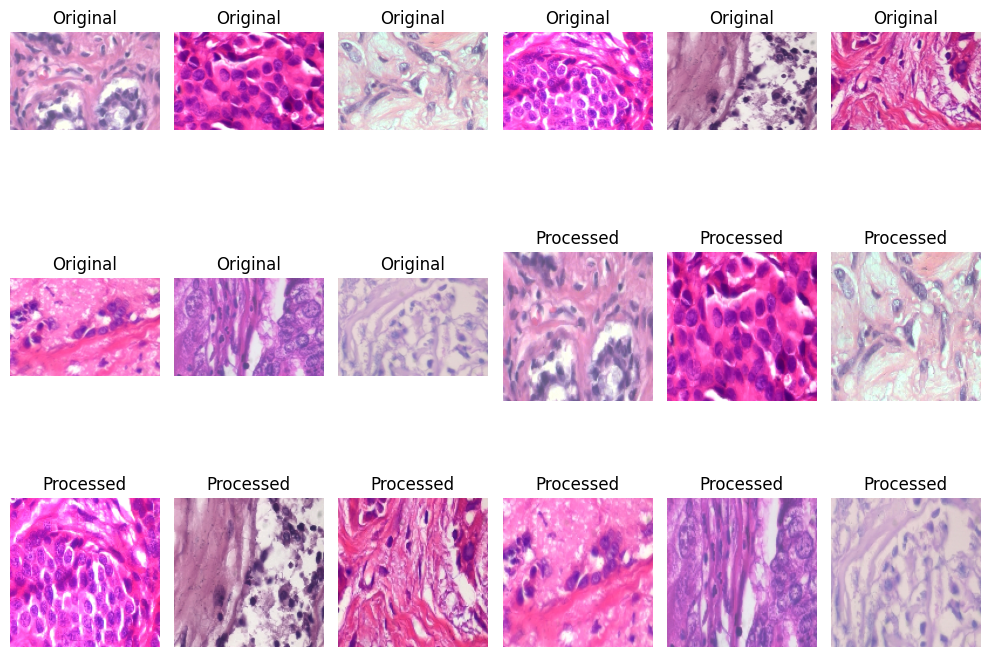

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random

# pick 9 random images
sample_paths = random.sample(list(df["image_path"]), 9)

plt.figure(figsize=(10,8))


# ORIGINAL IMAGES

for i, path in enumerate(sample_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 6, i+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")


# PREPROCESSED IMAGES

IMG_SIZE = 128

for i, path in enumerate(sample_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # normalize
    img = img / 255.0

    plt.subplot(3, 6, i+10)
    plt.imshow(img)
    plt.title("Processed")
    plt.axis("off")

plt.tight_layout()
plt.show()

## **Dataset Insights: Viaulisation**

                                          image_path      label
0  dataset/BreaKHis 400X/train/malignant/SOB_M_LC...  malignant
1  dataset/BreaKHis 400X/train/malignant/SOB_M_DC...  malignant
2  dataset/BreaKHis 400X/train/malignant/SOB_M_DC...  malignant
3  dataset/BreaKHis 400X/train/malignant/SOB_M_DC...  malignant
4  dataset/BreaKHis 400X/train/malignant/SOB_M_DC...  malignant
dataset shape: (1693, 2)
missing values:
 image_path    0
label         0
dtype: int64
class counts:
 label
malignant    1146
benign        547
Name: count, dtype: int64


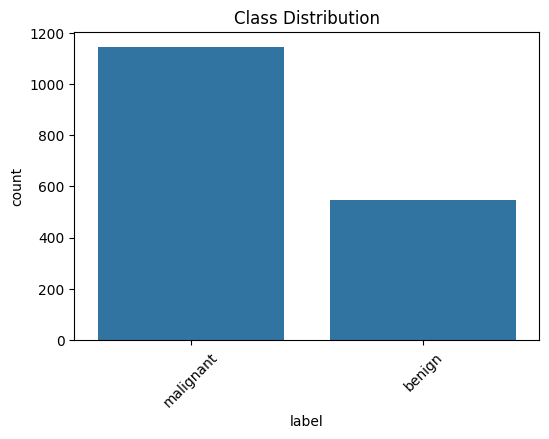

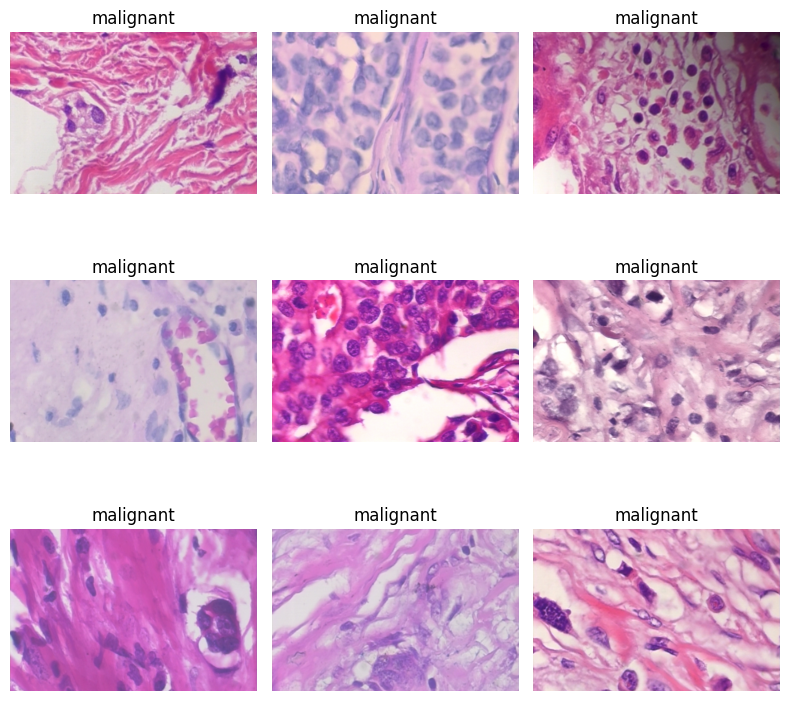

sample image sizes: [(460, 700, 3), (460, 700, 3), (460, 700, 3), (460, 700, 3), (460, 700, 3)]


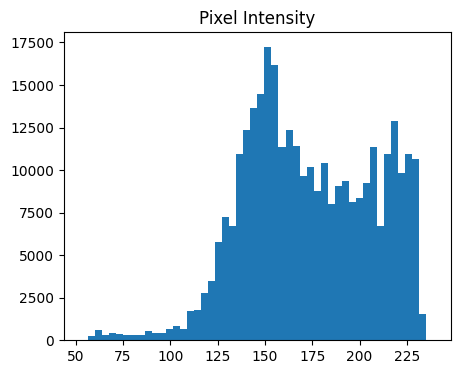

In [12]:
# basic dataset EDA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# show first few rows
print(df.head())

# dataset shape
print("dataset shape:", df.shape)

# check missing values
print("missing values:\n", df.isnull().sum())

# class distribution
print("class counts:\n", df["label"].value_counts())

# plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()


# show few sample images
plt.figure(figsize=(8,8))

for i in range(9):
    path = df["image_path"].iloc[i]
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(df["label"].iloc[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


# image size check (sample)
sizes = []

for path in df["image_path"].sample(100):
    img = cv2.imread(path)
    sizes.append(img.shape)

print("sample image sizes:", sizes[:5])


# simple histogram of one image
img = cv2.imread(df["image_path"].iloc[0], 0)

plt.figure(figsize=(5,4))
plt.hist(img.flatten(), bins=50)
plt.title("Pixel Intensity")
plt.show()

## **Model Development**

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


# CLASS WEIGHTS

classes = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(zip(range(len(classes)), weights))
print("class weights:", class_weights)


# CNN MODEL

cnn_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining CNN...")
cnn_history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights
)


# RESNET MODEL

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3))
)

for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining ResNet...")
resnet_history = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights
)


# VIT STYLE MODEL (EfficientNet)

vit_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3))
)

for layer in vit_base.layers[:-20]:
    layer.trainable = False

x = vit_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

vit_model = Model(inputs=vit_base.input, outputs=output)

vit_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining ViT-style model...")
vit_history = vit_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights
)


# EVALUATION

cnn_acc = cnn_model.evaluate(val_gen)[1]
resnet_acc = resnet_model.evaluate(val_gen)[1]
vit_acc = vit_model.evaluate(val_gen)[1]

print("\nFinal Results:")
print("CNN Accuracy:", cnn_acc)
print("ResNet Accuracy:", resnet_acc)
print("ViT Accuracy:", vit_acc)

class weights: {0: np.float64(1.5491990846681922), 1: np.float64(0.7382769901853872)}

Training CNN...
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.5975 - loss: 0.7467 - val_accuracy: 0.8437 - val_loss: 0.4952
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.7053 - loss: 0.5967 - val_accuracy: 0.8378 - val_loss: 0.5201
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.7400 - loss: 0.5780 - val_accuracy: 0.7198 - val_loss: 0.5586
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.7733 - loss: 0.5452 - val_accuracy: 0.6224 - val_loss: 0.8321
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.7806 - loss: 0.5343 - val_accuracy: 0.8614 - val_loss: 0.4462

Training ResNet...
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 166s 7s/step - accuracy: 0.5554 - loss: 0.6888 - val_accuracy: 0.3245 - val_loss: 0.7214
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 144s 6s/step - accuracy: 0.6603 - loss: 0.6255 - val_accuracy: 0.3245 - val_loss: 0.7053


In [14]:
# mobilenet model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# load pretrained mobilenet
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3))
)

# freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining MobileNetV2...")
mobilenet_history = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights
)

# evaluation
mobilenet_acc = mobilenet_model.evaluate(val_gen)[1]

print("\nMobileNet Accuracy:", mobilenet_acc)

/tmp/ipykernel_36014/166534283.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(



Training MobileNetV2...
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.5524 - loss: 0.7669 - val_accuracy: 0.4897 - val_loss: 0.8686
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6773 - loss: 0.6037 - val_accuracy: 0.5959 - val_loss: 0.7688
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7134 - loss: 0.5343 - val_accuracy: 0.5841 - val_loss: 0.8278
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7555 - loss: 0.4993 - val_accuracy: 0.4572 - val_loss: 1.2290
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7622 - loss: 0.4695 - val_accuracy: 0.5251 - val_loss: 1.0665
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5251 - loss: 1.0665

MobileNet Accuracy: 0.525073766708374


## **Model Evaluation**

Found 339 validated image filenames belonging to 2 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 914ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


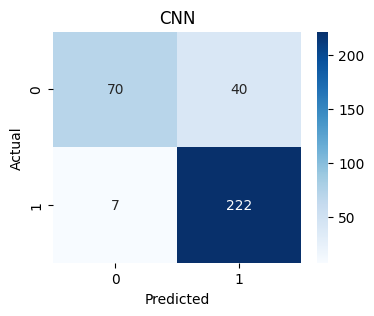

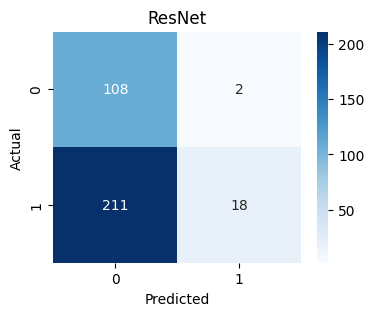

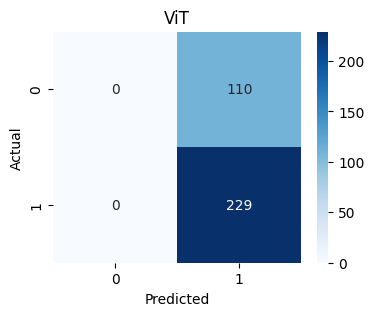

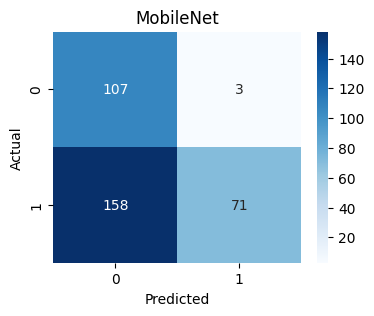


CNN Report
               precision    recall  f1-score   support

           0       0.91      0.64      0.75       110
           1       0.85      0.97      0.90       229

    accuracy                           0.86       339
   macro avg       0.88      0.80      0.83       339
weighted avg       0.87      0.86      0.85       339


ResNet Report
               precision    recall  f1-score   support

           0       0.34      0.98      0.50       110
           1       0.90      0.08      0.14       229

    accuracy                           0.37       339
   macro avg       0.62      0.53      0.32       339
weighted avg       0.72      0.37      0.26       339


ViT Report
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       110
           1       0.68      1.00      0.81       229

    accuracy                           0.68       339
   macro avg       0.34      0.50      0.40       339
weighted avg       0.46      0.6

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


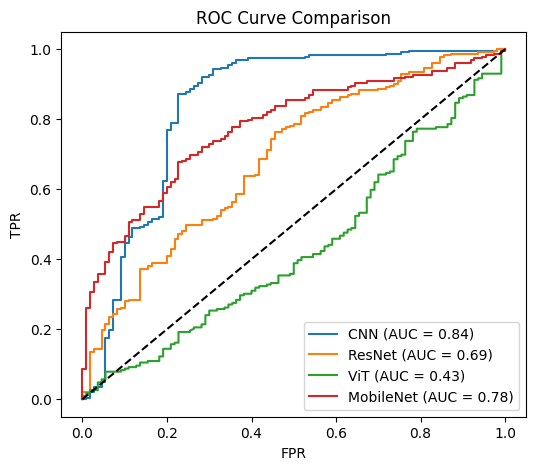

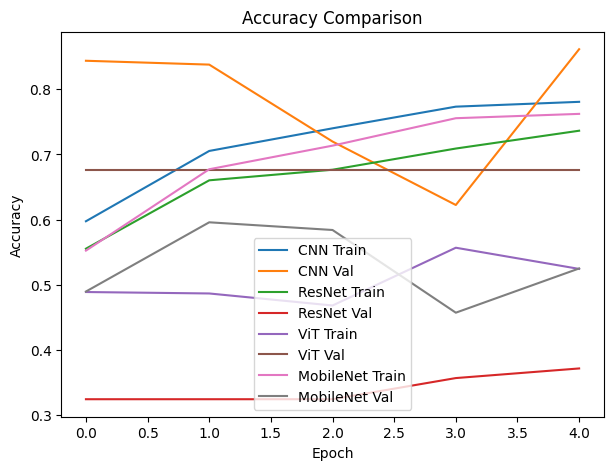

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 930ms/step - accuracy: 0.8614 - loss: 0.4462
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.3717 - loss: 0.7002
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6755 - loss: 0.6780
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5251 - loss: 1.0665


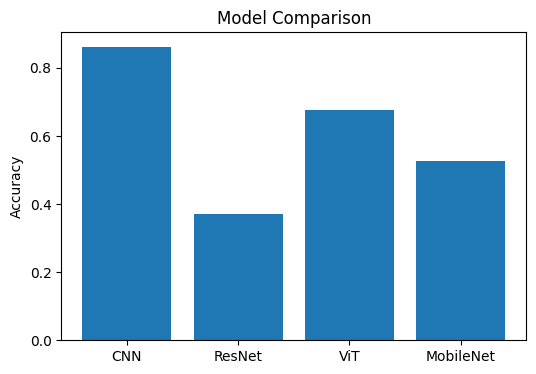

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# CREATE TEST GENERATOR

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_dataframe(
    val_df,   # using validation as test (safe)
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=64,
    shuffle=False
)


# TRUE LABELS

y_true = test_gen.classes


# PREDICTIONS

cnn_prob = cnn_model.predict(test_gen)
resnet_prob = resnet_model.predict(test_gen)
vit_prob = vit_model.predict(test_gen)
mobilenet_prob = mobilenet_model.predict(test_gen)

cnn_pred = (cnn_prob > 0.5).astype("int32")
resnet_pred = (resnet_prob > 0.5).astype("int32")
vit_pred = (vit_prob > 0.5).astype("int32")
mobilenet_pred = (mobilenet_prob > 0.5).astype("int32")


# CONFUSION MATRIX FUNCTION

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# CONFUSION MATRICES

plot_cm(y_true, cnn_pred, "CNN")
plot_cm(y_true, resnet_pred, "ResNet")
plot_cm(y_true, vit_pred, "ViT")
plot_cm(y_true, mobilenet_pred, "MobileNet")


# CLASSIFICATION REPORT

print("\nCNN Report\n", classification_report(y_true, cnn_pred))
print("\nResNet Report\n", classification_report(y_true, resnet_pred))
print("\nViT Report\n", classification_report(y_true, vit_pred))
print("\nMobileNet Report\n", classification_report(y_true, mobilenet_pred))


# ROC CURVES

plt.figure(figsize=(6,5))

fpr, tpr, _ = roc_curve(y_true, cnn_prob)
plt.plot(fpr, tpr, label="CNN (AUC = %.2f)" % auc(fpr, tpr))

fpr, tpr, _ = roc_curve(y_true, resnet_prob)
plt.plot(fpr, tpr, label="ResNet (AUC = %.2f)" % auc(fpr, tpr))

fpr, tpr, _ = roc_curve(y_true, vit_prob)
plt.plot(fpr, tpr, label="ViT (AUC = %.2f)" % auc(fpr, tpr))

fpr, tpr, _ = roc_curve(y_true, mobilenet_prob)
plt.plot(fpr, tpr, label="MobileNet (AUC = %.2f)" % auc(fpr, tpr))

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()


# TRAINING ACCURACY

plt.figure(figsize=(7,5))

plt.plot(cnn_history.history['accuracy'], label="CNN Train")
plt.plot(cnn_history.history['val_accuracy'], label="CNN Val")

plt.plot(resnet_history.history['accuracy'], label="ResNet Train")
plt.plot(resnet_history.history['val_accuracy'], label="ResNet Val")

plt.plot(vit_history.history['accuracy'], label="ViT Train")
plt.plot(vit_history.history['val_accuracy'], label="ViT Val")

plt.plot(mobilenet_history.history['accuracy'], label="MobileNet Train")
plt.plot(mobilenet_history.history['val_accuracy'], label="MobileNet Val")

plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# FINAL ACCURACY BAR

cnn_acc = cnn_model.evaluate(test_gen)[1]
resnet_acc = resnet_model.evaluate(test_gen)[1]
vit_acc = vit_model.evaluate(test_gen)[1]
mobilenet_acc = mobilenet_model.evaluate(test_gen)[1]

models = ["CNN", "ResNet", "ViT", "MobileNet"]
acc = [cnn_acc, resnet_acc, vit_acc, mobilenet_acc]

plt.figure(figsize=(6,4))
plt.bar(models, acc)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

## **Model Comparison**

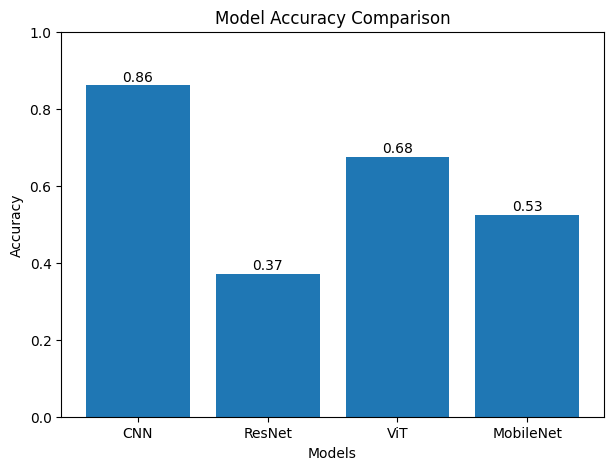

In [16]:
# evaluate all models once
cnn_acc = cnn_model.evaluate(test_gen, verbose=0)[1]
resnet_acc = resnet_model.evaluate(test_gen, verbose=0)[1]
vit_acc = vit_model.evaluate(test_gen, verbose=0)[1]
mobilenet_acc = mobilenet_model.evaluate(test_gen, verbose=0)[1]

# store values
models = ["CNN", "ResNet", "ViT", "MobileNet"]
accuracies = [cnn_acc, resnet_acc, vit_acc, mobilenet_acc]

# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
bars = plt.bar(models, accuracies)

# add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center')

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()